ERROR: Ignored the following versions that require a different python version: 1.21.2 Requires-Python >=3.7,<3.11; 1.21.3 Requires-Python >=3.7,<3.11; 1.21.4 Requires-Python >=3.7,<3.11; 1.21.5 Requires-Python >=3.7,<3.11; 1.21.6 Requires-Python >=3.7,<3.11
ERROR: Could not find a version that satisfies the requirement pandas==2.2.4 (from versions: 0.1, 0.2, 0.3.0, 0.4.0, 0.4.1, 0.4.2, 0.4.3, 0.5.0, 0.6.0, 0.6.1, 0.7.0, 0.7.1, 0.7.2, 0.7.3, 0.8.0, 0.8.1, 0.9.0, 0.9.1, 0.10.0, 0.10.1, 0.11.0, 0.12.0, 0.13.0, 0.13.1, 0.14.0, 0.14.1, 0.15.0, 0.15.1, 0.15.2, 0.16.0, 0.16.1, 0.16.2, 0.17.0, 0.17.1, 0.18.0, 0.18.1, 0.19.0, 0.19.1, 0.19.2, 0.20.0, 0.20.1, 0.20.2, 0.20.3, 0.21.0, 0.21.1, 0.22.0, 0.23.0, 0.23.1, 0.23.2, 0.23.3, 0.23.4, 0.24.0, 0.24.1, 0.24.2, 0.25.0, 0.25.1, 0.25.2, 0.25.3, 1.0.0, 1.0.1, 1.0.2, 1.0.3, 1.0.4, 1.0.5, 1.1.0, 1.1.1, 1.1.2, 1.1.3, 1.1.4, 1.1.5, 1.2.0, 1.2.1, 1.2.2, 1.2.3, 1.2.4, 1.2.5, 1.3.0, 1.3.1, 1.3.2, 1.3.3, 1.3.4, 1.3.5, 1.4.0rc0, 1.4.0, 1.4.1, 1.4.2, 1.4.3, 1

,email_count,phone_count,found_plain_passwords,context_score,score,risk_level,label
0,3,0,1,4,10,HIGH,1
1,4,2,0,2,10,HIGH,1
2,2,0,0,2,4,MEDIUM,0
3,5,0,0,3,8,HIGH,1
4,5,1,1,3,13,HIGH,1


Data splits -> Train: (140, 5) Val: (30, 5) Test: (30, 5)
Positive (HIGH) rate in dataset: 0.575

=== Model Test Metrics ===


,accuracy,precision,recall,f1,roc_auc,avg_precision,logloss
Logistic,1.0,1.0,1.0,1.0,1.0,1.0,0.187091
RandomForest,1.0,1.0,1.0,1.0,1.0,1.0,0.008584
XGBoost,1.0,1.0,1.0,1.0,1.0,1.0,0.017205



Best model (by F1): Logistic

Classification report (test):
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        13
           1     1.0000    1.0000    1.0000        17

    accuracy                         1.0000        30
   macro avg     1.0000    1.0000    1.0000        30
weighted avg     1.0000    1.0000    1.0000        30



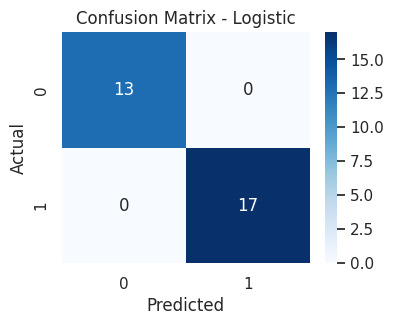

TP=17, FP=0, FN=0, TN=13
FPR (FP/(FP+TN)): 0.0
FNR (FN/(FN+TP)): 0.0


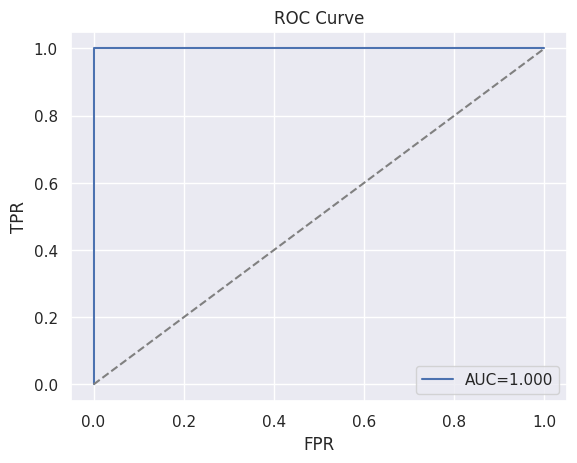

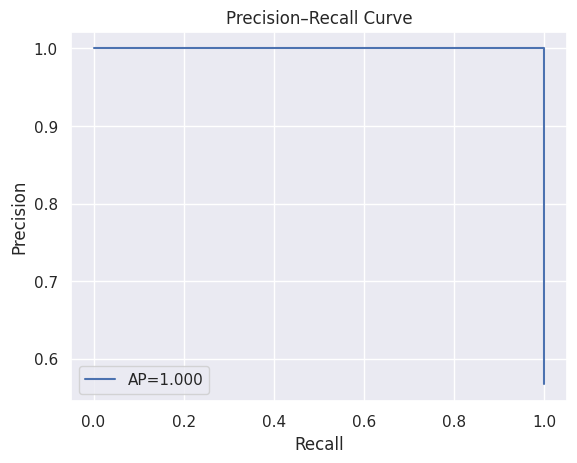

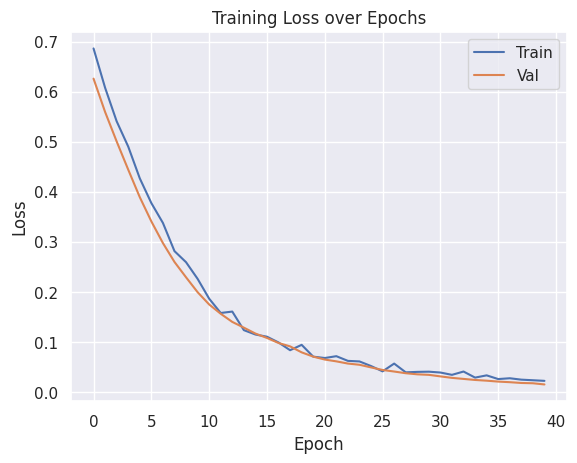


McNemar χ²=inf, p=0.000
→ Significant difference between RandomForest and XGBoost


In [ ]:
# ================================================================
# OSINT Risk Management Demo — Full Colab Script (paste & run)
# Author: Karline Deva Arputham R
# ================================================================

# -----------------------------
# 1) Install compatible packages
# -----------------------------
!pip install -q --upgrade pip
!pip install -q numpy==1.26.4 pandas==2.2.4 scikit-learn==1.3.2 seaborn==0.12.2 matplotlib==3.8.0 xgboost==1.8.5 statsmodels==0.14.0 tensorflow==2.19.0

# -----------------------------
# 2) Imports & quick sanity
# -----------------------------
import sys, os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set()
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score,
                             precision_score, recall_score, f1_score, roc_auc_score,
                             average_precision_score, log_loss)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from statsmodels.stats.contingency_tables import mcnemar
from tensorflow.keras import models as km, layers, optimizers
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

print("Python:", sys.version.split()[0], "| NumPy:", np.__version__, "| TensorFlow:", __import__('tensorflow').__version__)

# -----------------------------
# 3) Create synthetic 200-row dataset
# -----------------------------
N = 200
rng = np.random.RandomState(42)
rows = []
for i in range(N):
    email_count = rng.randint(0, 6)                 # 0..5
    phone_count = rng.randint(0, 3)                 # 0..2
    found_plain_passwords = int(rng.rand() < 0.25)  # ~25% chance
    context_score = rng.randint(0, 5)               # 0..4
    score = email_count + 2*phone_count + 3*found_plain_passwords + context_score
    if score >= 7:
        risk = "HIGH"
    elif score >= 3:
        risk = "MEDIUM"
    else:
        risk = "LOW"
    rows.append([email_count, phone_count, found_plain_passwords, context_score, score, risk])

df = pd.DataFrame(rows, columns=["email_count","phone_count","found_plain_passwords","context_score","score","risk_level"])
df['label'] = (df['risk_level']=="HIGH").astype(int)
df.to_csv("parsed_summary.csv", index=False)
print("Created synthetic dataset: parsed_summary.csv with shape", df.shape)
display(df.head())

# -----------------------------
# 4) Preprocess & split
# -----------------------------
features = ['email_count','phone_count','found_plain_passwords','context_score','score']
X = df[features].astype(float)
y = df['label'].values

# 70/15/15 approx
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.17647, stratify=y_temp, random_state=42)
print("Data splits -> Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Positive (HIGH) rate in dataset:", y.mean())

# -----------------------------
# 5) Define models
# -----------------------------
models = {
    "Logistic": LogisticRegression(max_iter=2000, class_weight='balanced', solver='liblinear'),
    "RandomForest": RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                                 scale_pos_weight=(np.sum(y_train==0)/np.sum(y_train==1)))
}

# -----------------------------
# 6) Train & evaluate on test
# -----------------------------
def eval_on_test(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    # predict_proba available for our classifiers
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        # fallback to decision_function then sigmoid
        try:
            dfun = model.decision_function(X_test)
            y_prob = 1 / (1 + np.exp(-dfun))
        except Exception:
            y_prob = np.zeros(len(y_pred))
    res = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_prob) if len(np.unique(y_test))>1 else float("nan"),
        "avg_precision": average_precision_score(y_test, y_prob) if len(np.unique(y_test))>1 else float("nan"),
        "logloss": log_loss(y_test, y_prob) if len(np.unique(y_test))>1 else float("nan")
    }
    return res, y_pred, y_prob

results, preds, probs = {}, {}, {}
for name, m in models.items():
    res, y_pred, y_prob = eval_on_test(m, X_train, y_train, X_test, y_test)
    results[name] = res
    preds[name] = y_pred
    probs[name] = y_prob

print("\n=== Model Test Metrics ===")
display(pd.DataFrame(results).T)

# -----------------------------
# 7) Confusion matrix & classification report for best model
# -----------------------------
best_name = max(results.items(), key=lambda kv: kv[1]['f1'])[0]
best_pred = preds[best_name]; best_prob = probs[best_name]
print("\nBest model (by F1):", best_name)
print("\nClassification report (test):")
print(classification_report(y_test, best_pred, digits=4))

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title(f"Confusion Matrix - {best_name}")
plt.show()

# Derived rates
if cm.size == 4:
    tn, fp, fn, tp = cm.ravel()
    print(f"TP={tp}, FP={fp}, FN={fn}, TN={tn}")
    print("FPR (FP/(FP+TN)):", fp/(fp+tn) if (fp+tn)>0 else None)
    print("FNR (FN/(FN+TP)):", fn/(fn+tp) if (fn+tp)>0 else None)

# -----------------------------
# 8) ROC & Precision-Recall curves
# -----------------------------
from sklearn.metrics import roc_curve, precision_recall_curve
if len(np.unique(y_test))>1:
    fpr, tpr, _ = roc_curve(y_test, best_prob)
    plt.figure(); plt.plot(fpr, tpr, label=f"AUC={roc_auc_score(y_test, best_prob):.3f}"); plt.plot([0,1],[0,1],'--',color='gray')
    plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC Curve'); plt.legend(); plt.show()

    prec, rec, _ = precision_recall_curve(y_test, best_prob)
    plt.figure(); plt.plot(rec, prec, label=f"AP={average_precision_score(y_test, best_prob):.3f}")
    plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Precision–Recall Curve'); plt.legend(); plt.show()
else:
    print("Only one class present in test set; ROC/PR curves are not available.")

# -----------------------------
# 9) Small Neural Network (training loss plot)
# -----------------------------
sc = StandardScaler().fit(X_train)
Xtr, Xval = sc.transform(X_train), sc.transform(X_val)

nn = km.Sequential([
    layers.Input(shape=(Xtr.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
nn.compile(optimizer=optimizers.Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
hist = nn.fit(Xtr, y_train, validation_data=(Xval, y_val), epochs=40, batch_size=16, verbose=0)

plt.figure()
plt.plot(hist.history['loss'], label='Train')
plt.plot(hist.history['val_loss'], label='Val')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Training Loss over Epochs'); plt.legend(); plt.show()

# -----------------------------
# 10) McNemar test between RandomForest and XGBoost
# -----------------------------
predA, predB = preds['RandomForest'], preds['XGBoost']
b = int(np.sum((predA != y_test) & (predB == y_test)))  # A wrong, B correct
c = int(np.sum((predA == y_test) & (predB != y_test)))  # A correct, B wrong
table = [[0, b], [c, 0]]
res = mcnemar(table, exact=False, correction=True)
print(f"\nMcNemar χ²={res.statistic:.3f}, p={res.pvalue:.3f}")
if res.pvalue < 0.05:
    print("→ Significant difference between RandomForest and XGBoost")
else:
    print("→ No significant difference between RandomForest and XGBoost")


